In [29]:
import sys
import subprocess

# Lista de librerías esenciales para Deep Learning, manejo de datos y visualización
packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

In [30]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

# Configuramos el dataset a 'breastmnist' para trabajar con ultrasonidos de mama
data_flag = "breastmnist"

# Obtiene la información y metadatos específicos del dataset seleccionado
info = INFO[data_flag]

# Carga dinámicamente la clase correspondiente de MedMNIST para BreastMNIST
DataClass = getattr(medmnist, info["python_class"])

# Muestra la información general del dataset
info

{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [31]:
import torchvision.transforms as T

# Define la transformación básica para convertir las imágenes de BreastMNIST a tensores y escalar píxeles a [0, 1]
transform_basic = T.Compose([
    T.ToTensor()
])

# Carga y descarga (si es necesario) el conjunto de entrenamiento de BreastMNIST
train_dataset = DataClass(split="train", transform=transform_basic, download=True)

# Carga el conjunto de validación
val_dataset = DataClass(split="val", transform=transform_basic, download=True)

# Carga el conjunto de prueba
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

# Muestra el número total de imágenes en cada partición (train, val, test)
len(train_dataset), len(val_dataset), len(test_dataset)

100%|██████████| 560k/560k [00:01<00:00, 449kB/s]


(546, 78, 156)

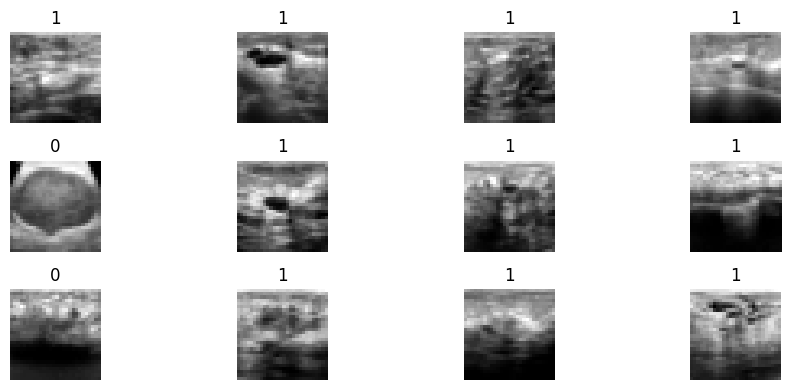

In [32]:
import matplotlib.pyplot as plt

def show_batch(dataset, n=12):
    # Configura el tamaño de la ventana de la figura
    plt.figure(figsize=(10, 4))

    for i in range(n):
        # Obtiene la imagen (x) y su etiqueta (y) del dataset
        x, y = dataset[i]

        # Crea una subgrilla de 3 filas por 4 columnas para mostrar 12 imágenes en total
        plt.subplot(3, 4, i+1)

        # Como BreastMNIST es escala de grises (1 canal), eliminamos la dimensión del canal con squeeze(0)
        img = x.squeeze(0)

        # Muestra la imagen en escala de grises
        plt.imshow(img, cmap="gray")

        # Muestra la etiqueta numérica de la clase correspondiente (ej. 0 o 1)
        plt.title(int(y.item()))

        # Oculta los ejes numéricos para una visualización más limpia
        plt.axis("off")

    # Ajusta automáticamente el diseño para que los elementos no se encimen
    plt.tight_layout()
    plt.show()

# Ejecuta la función para mostrar un lote de 12 imágenes del conjunto de entrenamiento de BreastMNIST
show_batch(train_dataset, n=12)

In [33]:
import torch

# Detecta automáticamente si hay una GPU disponible en Google Colab para acelerar los cálculos.
# Si no hay GPU activa, utilizará el procesador principal (CPU) por defecto.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cpu')

In [34]:
from torch.utils.data import DataLoader

# Define el tamaño de lote (número de imágenes de ultrasonido que la red procesará simultáneamente en cada paso)
batch_size = 128

# Crea el cargador de datos para el entrenamiento (mezclando las imágenes en cada época para evitar sesgos)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Crea el cargador de datos para la validación (sin mezclar para mantener consistencia en las métricas)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Crea el cargador de datos para la prueba final
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Extrae un lote de prueba para verificar las dimensiones de los tensores de imágenes (x) y etiquetas (y)
next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

In [47]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Estabiliza los saltos en la pérdida
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3), # Evita que se memorice y ayuda a que las métricas crezcan juntas
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Volvemos a instanciar el modelo con esta arquitectura
model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [48]:
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        # Obtenemos las probabilidades para ambas clases con Softmax
        probs_multi = torch.softmax(logits, dim=1)

        # Probabilidad de la clase positiva (para el ROC-AUC)
        probs = probs_multi[:, 1] if logits.shape[1] > 1 else torch.sigmoid(logits).squeeze(1)

        # Usamos argmax para seleccionar la clase con mayor probabilidad de forma natural
        preds = torch.argmax(probs_multi, dim=1) if logits.shape[1] > 1 else (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = balanced_accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

In [67]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=5e-4, weight_decay=1e-4)
epochs = 22

history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    model_scratch.eval()
    val_losses = []
    with torch.no_grad():
        for x_v, y_v in val_loader:
            x_v, y_v = x_v.to(device), y_v.to(device).long().squeeze(1)
            loss_v = criterion(model_scratch(x_v), y_v)
            val_losses.append(loss_v.item())
    val_loss = float(np.mean(val_losses))

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | train_loss=0.2045 | val_loss=1.2616 | val_acc=0.7331 | val_auc=0.8438


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | train_loss=0.1221 | val_loss=1.9638 | val_acc=0.7105 | val_auc=0.9373


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 20 | train_loss=0.0015 | val_loss=0.4171 | val_acc=0.8634 | val_auc=0.9248


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 21 | train_loss=0.0014 | val_loss=0.4321 | val_acc=0.8722 | val_auc=0.9240


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 22 | train_loss=0.0013 | val_loss=0.4462 | val_acc=0.8722 | val_auc=0.9215


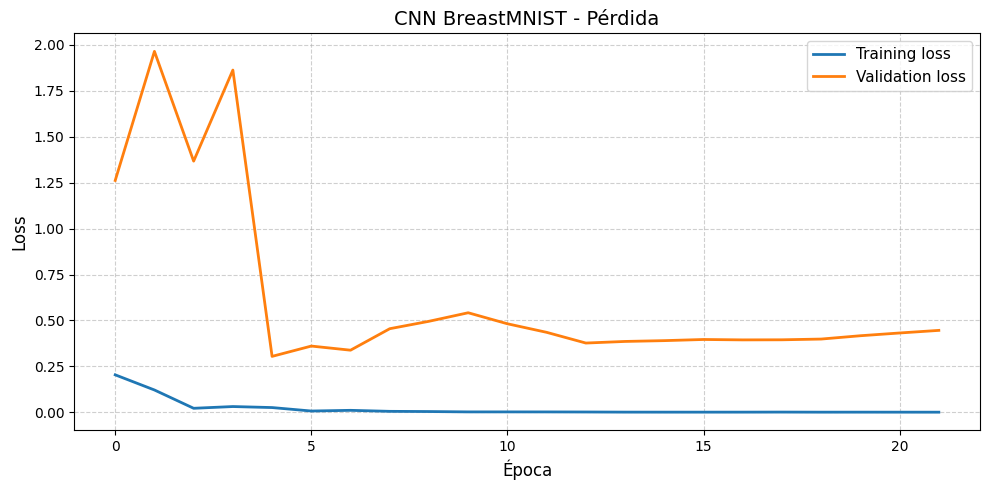

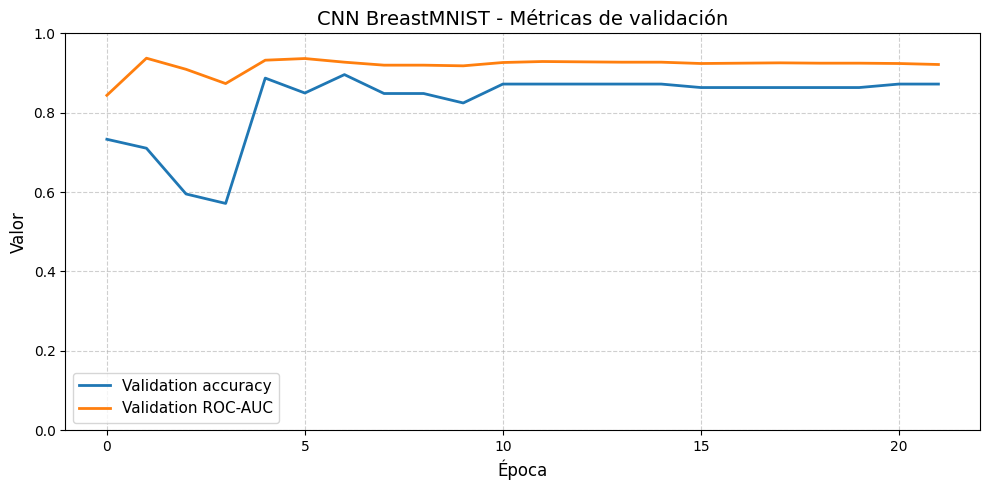

In [68]:
import matplotlib.pyplot as plt

# PRIMER GRÁFICO: Pérdida (Loss) y validacion
plt.figure(figsize=(10, 5))
plt.plot(history_scratch["train_loss"], label="Training loss", linewidth=2)
plt.plot(history_scratch["val_loss"], label="Validation loss", linewidth=2)

plt.title("CNN BreastMNIST - Pérdida", fontsize=14)
plt.xlabel("Época", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# SEGUNDO GRÁFICO: Métricas de validación
plt.figure(figsize=(10, 5))
plt.plot(history_scratch["val_acc"], label="Validation accuracy", linewidth=2)
plt.plot(history_scratch["val_auc"], label="Validation ROC-AUC", linewidth=2)
plt.ylim(0.0, 1.0)

plt.title("CNN BreastMNIST - Métricas de validación", fontsize=14)
plt.xlabel("Época", fontsize=12)
plt.ylabel("Valor", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [69]:
from sklearn.metrics import classification_report, confusion_matrix

# Evalúa el modelo optimizado utilizando el conjunto de datos de prueba (test_loader)
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)

# Muestra en pantalla la precisión balanceada obtenida en la prueba
print(f"Test accuracy: {test_acc:.4f}")

# Muestra en pantalla el área bajo la curva ROC (ROC-AUC) en la prueba
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()

# Imprime un reporte detallado con métricas clave (precision, recall, f1-score) por clase con 4 decimales
print(classification_report(y_true, y_pred, digits=4))

# Calcula la matriz de confusión para ver los aciertos y errores detallados por clase
cm = confusion_matrix(y_true, y_pred)

# Muestra la matriz de confusión resultante
cm

Test accuracy: 0.7550
Test ROC-AUC:  0.8779

              precision    recall  f1-score   support

           0     0.7742    0.5714    0.6575        42
           1     0.8560    0.9386    0.8954       114

    accuracy                         0.8397       156
   macro avg     0.8151    0.7550    0.7765       156
weighted avg     0.8340    0.8397    0.8314       156



array([[ 24,  18],
       [  7, 107]])

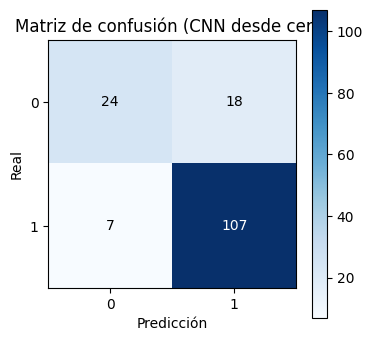

In [70]:
import matplotlib.pyplot as plt

# Configura el tamaño de la figura para que la matriz sea cuadrada y compacta
plt.figure(figsize=(4, 4))

# Muestra la matriz de confusión como una imagen con colores (mapa de calor)
plt.imshow(cm, cmap="Blues")

# Asigna el título y las etiquetas de los ejes
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")

# Define las posiciones de las marcas en los ejes X e Y (para clasificación binaria 0 y 1)
plt.xticks([0, 1])
plt.yticks([0, 1])

# Recorre cada celda de la matriz de 2x2 para escribir numéricamente la cantidad de muestras en su interior
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max()/2 else "white")

# Agrega una barra lateral de colores para indicar la escala de frecuencia
plt.colorbar()

# Muestra la gráfica final
plt.show()

In [71]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Define una serie de transformaciones de aumento de datos para el entrenamiento
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),                   # Rota la imagen aleatoriamente hasta 10 grados
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Desplaza ligeramente la imagen (hasta un 5% horizontal y verticalmente)
    T.ToTensor()                                     # Convierte la imagen a un tensor de PyTorch
])

# Carga el dataset de entrenamiento aplicando las transformaciones de aumento y descargándolo si es necesario
train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)

# Crea el DataLoader optimizado para el entrenamiento con aumento de datos
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [72]:
import torch.nn as nn
import torch.optim as optim

# Instancia una nueva arquitectura SimpleCNN y la envía al dispositivo (GPU o CPU)
model_aug = SimpleCNN(num_classes=num_classes).to(device)

# Define la función de pérdida y el optimizador Adam con tasa de aprendizaje estándar de 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=1e-3)

# Define el número de épocas para esta fase de entrenamiento con aumento de datos
epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

# Bucle principal de entrenamiento y evaluación por cada época
for epoch in range(1, epochs + 1):
    # Entrena la red usando el cargador con aumento de datos (train_loader_aug)
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)

    # Evalúa el modelo en el conjunto de validación estándar (val_loader)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    # Guarda los resultados en el historial de aumento de datos
    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    # Imprime el resumen del progreso de la época actual
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | train_loss=0.6000 | val_acc=0.5000 | val_auc=0.5865


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | train_loss=0.5242 | val_acc=0.5000 | val_auc=0.6700


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 04 | train_loss=0.4955 | val_acc=0.5000 | val_auc=0.7937


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 05 | train_loss=0.4615 | val_acc=0.5000 | val_auc=0.7728


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 06 | train_loss=0.4871 | val_acc=0.5000 | val_auc=0.8329


In [73]:
# Evalúa el modelo entrenado con aumento de datos utilizando el conjunto de prueba
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)

# Imprime y compara los resultados de precisión y ROC-AUC sin aumento de datos frente a con aumento de datos
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Sin augmentation  | test_acc=0.7550 | test_auc=0.8779
Con augmentation  | test_acc=0.5000 | test_auc=0.8177


In [74]:
import torchvision.models as models

# Transformaciones para el entrenamiento con transferencia de aprendizaje y aumento de datos
transform_tl_train = T.Compose([
    T.Resize((224, 224)),                          # Redimensiona la imagen al tamaño estándar esperado por los modelos (224x224)
    T.RandomRotation(degrees=10),                   # Rota la imagen aleatoriamente
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Desplaza ligeramente la imagen
    T.ToTensor(),                                     # Convierte la imagen a un tensor de PyTorch
    T.Lambda(lambda x: x.repeat(3, 1, 1))            # Duplica el canal de escala de grises 3 veces para simular una imagen RGB a color
])

# Transformaciones para validación y prueba (sin aumento de datos)
transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))            # Convierte la entrada de 1 canal a 3 canales (RGB simulado)
])

# Carga los datasets adaptados para Transfer Learning
train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

# Crea los DataLoaders específicos para el flujo de Transfer Learning (lotes de 64)
train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Comprueba las dimensiones del primer lote de tensores de entrenamiento (debe mostrar [64, 3, 224, 224])
next(iter(train_loader_tl))[0].shape

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([64, 3, 224, 224])

In [75]:
import torchvision.models as models
import torch.nn as nn

# Carga el modelo ResNet18 con sus pesos preentrenados por defecto (ImageNet)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Obtiene el número de características de entrada de la capa totalmente conectada original
in_features = resnet.fc.in_features

# Reemplaza la capa lineal final por una nueva adaptada al número de clases de BreastMNIST
resnet.fc = nn.Linear(in_features, num_classes)

# Envía el modelo al dispositivo configurado (GPU o CPU)
resnet = resnet.to(device)

# Congela todos los parámetros (pesos y sesgos) de la red para que no se modifiquen durante el entrenamiento base
for name, param in resnet.named_parameters():
    param.requires_grad = False

# Habilita el gradiente únicamente para los parámetros de la nueva capa final (fc)
for param in resnet.fc.parameters():
    param.requires_grad = True

# Muestra la estructura final del modelo ResNet configurado
resnet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 28.8MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [76]:
import torch.nn as nn
import torch.optim as optim

# Define la función de pérdida (CrossEntropyLoss)
criterion = nn.CrossEntropyLoss()

# Configura el optimizador Adam optimizando únicamente los parámetros de la capa final (resnet.fc)
optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-3)

# Define el número de épocas para esta primera etapa de ajuste (4 épocas)
epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

# Bucle de entrenamiento por cada época para la Etapa 1
for epoch in range(1, epochs + 1):
    # Entrena la red usando el cargador adaptado para transferencia y la función train_one_epoch
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)

    # Evalúa el modelo en el conjunto de validación adaptado (val_loader_tl)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    # Almacena las métricas obtenidas en el historial de la etapa 1
    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    # Imprime el progreso detallado de la época actual
    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage1 Epoch 01 | train_loss=0.6180 | val_acc=0.5000 | val_auc=0.4010


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 02 | train_loss=0.5771 | val_acc=0.5113 | val_auc=0.5430


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 03 | train_loss=0.5476 | val_acc=0.6040 | val_auc=0.6441


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage1 Epoch 04 | train_loss=0.5085 | val_acc=0.5990 | val_auc=0.7160


In [77]:
# Recorre todos los parámetros nombrados del modelo ResNet
for name, param in resnet.named_parameters():
    # Habilita el gradiente (permite su entrenamiento) solo para el último bloque convolucional (layer4) y la capa de clasificación (fc)
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

# Filtra y recopila únicamente los parámetros del modelo que tienen habilitado el entrenamiento
trainable_params = [p for p in resnet.parameters() if p.requires_grad]

# Muestra el número total de tensores de parámetros que serán entrenados en esta etapa
len(trainable_params)

17

In [78]:
import torch.optim as optim

# Configura el optimizador Adam únicamente para los parámetros habilitados (trainable_params)
# utilizando una tasa de aprendizaje más baja (1e-4) para no alterar drásticamente lo ya aprendido
optimizer = optim.Adam(trainable_params, lr=1e-4)

# Define el número de épocas para esta segunda etapa de ajuste fino (4 épocas)
epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

# Bucle de entrenamiento por cada época para la Etapa 2
for epoch in range(1, epochs + 1):
    # Entrena el modelo utilizando el cargador adaptado para transferencia
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)

    # Evalúa el rendimiento del modelo en el conjunto de validación adaptado
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    # Almacena las métricas obtenidas en el historial de la etapa 2
    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    # Imprime el progreso detallado de la época actual para la segunda etapa
    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 01 | train_loss=0.4703 | val_acc=0.7055 | val_auc=0.8338


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 02 | train_loss=0.3415 | val_acc=0.6429 | val_auc=0.8864


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 03 | train_loss=0.2871 | val_acc=0.7055 | val_auc=0.9190


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Stage2 Epoch 04 | train_loss=0.2396 | val_acc=0.7531 | val_auc=0.9390


In [79]:
from sklearn.metrics import classification_report, confusion_matrix

# Evalúa el modelo de ResNet18 entrenado con Transfer Learning utilizando el conjunto de prueba adaptado
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)

# Imprime la precisión balanceada obtenida por transferencia de aprendizaje en la prueba
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()

# Muestra el reporte detallado con las métricas de rendimiento (precision, recall, f1-score) por clase
print(classification_report(y_true_tl, y_pred_tl, digits=4))

# Calcula la matriz de confusión para el modelo de transferencia de aprendizaje
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

# Muestra la matriz de confusión resultante
cm_tl

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Transfer learning | test_acc=0.7431 | test_auc=0.8935

              precision    recall  f1-score   support

           0     0.7667    0.5476    0.6389        42
           1     0.8492    0.9386    0.8917       114

    accuracy                         0.8333       156
   macro avg     0.8079    0.7431    0.7653       156
weighted avg     0.8270    0.8333    0.8236       156



array([[ 23,  19],
       [  7, 107]])

In [80]:
print("Resumen de resultados en test")

# Imprime las métricas finales del modelo base entrenado desde cero (sin aumento de datos)
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")

# Imprime las métricas del modelo entrenado desde cero aplicando aumento de datos (data augmentation)
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")

# Imprime las métricas finales del modelo avanzado utilizando Transfer Learning con ResNet18
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.7550 | auc=0.8779
CNN desde cero (con aug)  | acc=0.5000 | auc=0.8177
Transfer learning (ResNet) | acc=0.7431 | auc=0.8935


In [81]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    # Coloca el modelo en modo de evaluación
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    # Gancho (hook) para capturar las activaciones (salidas) del último bloque convolucional (layer4)
    def forward_hook(module, inp, out):
        activations["value"] = out

    # Gancho para capturar los gradientes que fluyen hacia atrás en el layer4
    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    # Registra los ganchos en el layer4 de ResNet
    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    # Realiza la predicción (forward pass) añadiendo una dimensión de lote (unsqueeze)
    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    # Obtiene la puntuación de la clase objetivo para calcular el gradiente
    score = logits[0, target_class]
    model.zero_grad()
    score.backward() # Propagación hacia atrás (backward pass) para calcular gradientes

    act = activations["value"][0]
    grad = gradients["value"][0]

    # Calcula los pesos globales promediando los gradientes espaciales
    weights = torch.mean(grad, dim=(1, 2))
    # Combina linealmente las activaciones ponderadas
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    # Aplica ReLU para conservar solo las características que influyen positivamente
    cam = torch.relu(cam)
    # Normaliza el mapa de calor entre 0 y 1 para su correcta visualización
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # Remueve los ganchos para limpiar la memoria del modelo
    handle_fwd.remove()
    handle_bwd.remove()

    # Retorna el mapa de calor convertido a un arreglo de NumPy y la clase analizada
    return cam.detach().cpu().numpy(), target_class

/tmp/ipykernel_1093/3179506929.py:31: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  score.backward() # Propagación hacia atrás (backward pass) para calcular gradientes


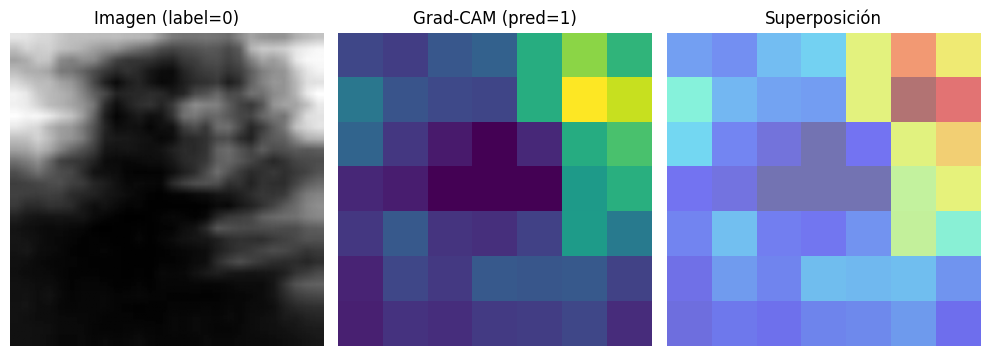

In [82]:
import matplotlib.pyplot as plt

# Selecciona el índice de la imagen de prueba que se va a analizar y explicar
idx = 0
x, y = test_dataset_tl[idx]

# Genera el mapa de activación Grad-CAM y la clase predicha utilizando el modelo ResNet y la imagen seleccionada
cam, pred_class = grad_cam(resnet, x)

# Extrae el primer canal de la imagen para visualizarla en escala de grises
img = x[0].numpy()
plt.figure(figsize=(10, 4))

# Panel 1: Muestra la imagen original en escala de grises junto con su etiqueta real
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

# Panel 2: Muestra el mapa de calor Grad-CAM aislado indicando la clase predicha por el modelo
plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

# Panel 3: Superpone el mapa de calor sobre la imagen original en escala de grises para ver la región de interés médica exacta
plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5, cmap="jet")  # alpha añade transparencia al mapa de calor
plt.title("Superposición")
plt.axis("off")

# Ajusta el diseño de los subplots de manera compacta y limpia
plt.tight_layout()
plt.show()

In [ ]:
import os

# Crea una carpeta llamada "models" si es que aún no existe (exist_ok=True evita errores si ya fue creada)
os.makedirs("models", exist_ok=True)

# Guarda los pesos (state_dict) del modelo entrenado desde cero (sin aumento de datos)
torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")

# Guarda los pesos del modelo entrenado desde cero aplicando aumento de datos (data augmentation)
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")

# Guarda los pesos del modelo avanzado basado en Transfer Learning (ResNet18)
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

# Retorna la lista con las rutas de los tres archivos de modelos guardados exitosamente
["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]